# 06 — Error Analysis, Directional Classification, Shortlists and Uncertainty

**Inputs:** out-of-fold predictions from Notebook 04 plus the longitudinal feature table  
**Outputs:** selection coverage, subgroup/error diagnostics, direct and derived direction models, season-specific top-20 retrieval, prediction intervals and player-cluster bootstrap comparisons.

This final analytical notebook moves beyond average regression error. It asks where predictions fail, which player populations are actually represented by the scored sample, whether the practical question of **improve / stable / regress** is better addressed directly as classification, how model rankings change for scouting-style shortlist retrieval, and how much uncertainty surrounds point predictions.

All diagnostic claims are based on held-out outer-fold predictions. Named extreme cases are descriptive examples, not causal explanations: the public dataset cannot identify every injury, tactical, contractual or personal cause of a performance change.

**Report mapping:** Chapter 4 Objectives 7–9 / error analysis, directional prediction, practical usefulness and uncertainty.


In [1]:
from pathlib import Path
import sys, json, warnings, math
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb

ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
from src.analysis_utils import (
    paths, OUTER_FOLDS, FEATURE_COLS, TARGET, build_supervised_sample, split_outer,
    inner_chronological_split, prepare_train_test, regression_metrics, lead_series
)
P=paths(ROOT)
with open(P['config']/'model_config.json',encoding='utf-8') as f: CFG=json.load(f)
SEED=CFG['random_seed']; THRESH=float(CFG['direction_threshold'])
warnings.filterwarnings('ignore')

feat=pd.read_csv(P['processed']/'Longitudinal_Features_Dataset.csv',dtype={'season':str})
feat_all,elig=build_supervised_sample(feat)
oof=pd.read_csv(P['predictions']/'04_out_of_fold_predictions.csv')
print('OOF rows:',len(oof),'Supervised transitions:',len(elig))
assert len(oof)==4742


OOF rows: 4742 Supervised transitions: 8350


## 1. Selection coverage — who reaches the scored sample?

The regression metrics are conditional on a player having a valid next-season role-specific target. For every eligible current-season player in the four forecast-origin cohorts, this audit distinguishes four outcomes: included; absent in the next season; observed but below/otherwise ineligible for the next-season target; or target-eligible but changing broad role. This prevents the excluded population from disappearing into an unexplained missing-value count.


In [2]:
tmp=feat.copy(); tmp['observed_marker']=1.0
tmp['next_observed']=lead_series(tmp,'observed_marker',1)
tmp['rank_t1']=lead_series(tmp,'perf_rank_t',1)
tmp['role_t1']=lead_series(tmp,'role',1)
candidates=tmp[tmp['perf_rank_t'].notna() & tmp['season_idx'].isin([f['test'] for f in OUTER_FOLDS])].copy()
conds=[
    candidates['next_observed'].isna(),
    candidates['next_observed'].notna() & candidates['rank_t1'].isna(),
    candidates['rank_t1'].notna() & (candidates['role_t1']!=candidates['role'])
]
choices=['No next-season observation','Next season observed but target-ineligible','Next season eligible but role changed']
candidates['selection_outcome']=np.select(conds,choices,default='Included in evaluation')
sel=(candidates['selection_outcome'].value_counts().rename_axis('selection_outcome').reset_index(name='n'))
sel['share']=sel['n']/len(candidates)
display(sel)
assert len(candidates)==7416
assert dict(zip(sel.selection_outcome,sel.n))['Included in evaluation']==4742
sel.to_csv(P['tables']/'06_selection_coverage.csv',index=False)


,selection_outcome,n,share
0,Included in evaluation,4742,0.639428
1,No next-season observation,1534,0.206850
2,Next season observed but target-ineligible,714,0.096278
3,Next season eligible but role changed,426,0.057443


## 2. XGBoost residual and subgroup analysis

XGBoost is used for the detailed point-error audit because it has the lowest pooled regression MAE in Notebook 04. Positive residuals (`actual − predicted`) are underpredictions; negative residuals are overpredictions. Subgroup differences are descriptive associations within the held-out population and should not be read causally.


In [3]:
oof['residual_xgb']=oof[TARGET]-oof['pred_xgboost']
oof['abs_error_xgb']=oof['residual_xgb'].abs()
# Reporting groups
age_bins=[0,20,24,28,32,100]; age_labels=['U21','21-24','25-28','29-32','33+']
oof['age_band']=pd.cut(oof['age_'],bins=age_bins,labels=age_labels,right=True)
minutes_cut=float(elig['minutes_t'].median())
oof['minutes_band']=np.where(oof['minutes_t']>=minutes_cut,'High (>=median)','Low (<median)')
oof['history_band']=np.select([oof['n_hist_seasons']==0,oof['n_hist_seasons']==1],['No history','One prior season'],default='Two or more prior seasons')
ti=oof['transfer_indicator']
oof['transfer_cat']=np.select([ti.isna(),ti==1,ti==0],['Unknown (no prior season)','Transferred','Not transferred'],default='Unknown')
oof['starting_rank_band']=pd.cut(oof['perf_rank_t'],bins=[0,20,40,60,80,100.0001],labels=['0-20','20-40','40-60','60-80','80-100'],include_lowest=True)

def subgroup_table(col):
    rows=[]
    for cat,g in oof.groupby(col,observed=True):
        rows.append({'breakdown':col,'category':str(cat),**regression_metrics(g[TARGET],g['pred_xgboost'])})
    return pd.DataFrame(rows)

subgroups=pd.concat([subgroup_table(x) for x in ['role','age_band','minutes_band','history_band','transfer_cat','starting_rank_band','target_season','league_primary']],ignore_index=True)
display(subgroups[subgroups['breakdown'].isin(['role','minutes_band','history_band'])][['breakdown','category','n','MAE','RMSE','Spearman']].round(3))
subgroups.to_csv(P['tables']/'06_xgboost_subgroup_metrics.csv',index=False)

under=oof.nlargest(30,'residual_xgb')[['player_id','player','forecast_origin_season','target_season','role','perf_rank_t',TARGET,'pred_xgboost','residual_xgb']]
over=oof.nsmallest(30,'residual_xgb')[['player_id','player','forecast_origin_season','target_season','role','perf_rank_t',TARGET,'pred_xgboost','residual_xgb']]
under.to_csv(P['tables']/'06_largest_xgb_underpredictions.csv',index=False)
over.to_csv(P['tables']/'06_largest_xgb_overpredictions.csv',index=False)
print('Largest underpredictions:'); display(under.head(5).round(3))
print('Largest overpredictions:'); display(over.head(5).round(3))


,breakdown,category,n,MAE,RMSE,Spearman
0,role,DF,2121,18.636,22.775,0.603
1,role,FW,1067,17.888,22.383,0.637
2,role,MF,1554,14.734,18.644,0.753
8,minutes_band,High (>=median),2331,15.783,19.804,0.718
9,minutes_band,Low (<median),2411,18.548,22.867,0.599
10,history_band,No history,579,18.842,23.384,0.524
11,history_band,One prior season,675,16.813,20.815,0.634
12,history_band,Two or more prior seasons,3488,16.987,21.187,0.681


Largest underpredictions:


,player_id,player,forecast_origin_season,target_season,role,perf_rank_t,rank_t1,pred_xgboost,residual_xgb
2722,Enes Ünal||1997,Enes Ünal,2022/23,2023/24,FW,14.537,94.027,24.099,69.928
2523,Arne Maier||1999,Arne Maier,2022/23,2023/24,MF,6.181,92.243,22.317,69.925
2617,Cristhian Stuani||1986,Cristhian Stuani,2022/23,2023/24,FW,38.106,99.779,29.941,69.838
2569,Brennan Johnson||2001,Brennan Johnson,2022/23,2023/24,FW,7.048,92.257,22.505,69.752
1374,Callum Wilson||1992,Callum Wilson,2021/22,2022/23,FW,7.399,87.665,19.056,68.609


Largest overpredictions:


,player_id,player,forecast_origin_season,target_season,role,perf_rank_t,rank_t1,pred_xgboost,residual_xgb
1860,Lucas Hernández||1996,Lucas Hernández,2021/22,2022/23,DF,92.258,6.138,86.154,-80.016
3406,Ruslan Malinovskyi||1993,Ruslan Malinovskyi,2022/23,2023/24,MF,89.857,17.201,93.460,-76.259
2158,Remo Freuler||1992,Remo Freuler,2021/22,2022/23,MF,84.186,2.694,75.885,-73.191
85,Anthony Martial||1995,Anthony Martial,2020/21,2021/22,FW,74.944,1.794,69.186,-67.393
967,Roberto Massimo||2000,Roberto Massimo,2020/21,2021/22,DF,78.312,6.968,70.911,-63.944


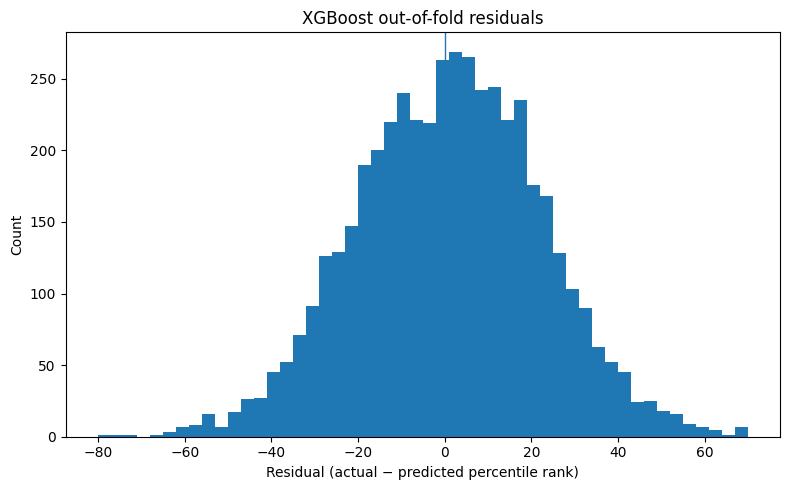

In [4]:
fig,ax=plt.subplots(figsize=(8,5))
ax.hist(oof['residual_xgb'],bins=50)
ax.axvline(0,linewidth=1)
ax.set_xlabel('Residual (actual − predicted percentile rank)')
ax.set_ylabel('Count')
ax.set_title('XGBoost out-of-fold residuals')
fig.tight_layout(); fig.savefig(P['figures']/'06_xgboost_residual_distribution.png',dpi=160,bbox_inches='tight'); plt.show()


## 3. Directional outcome: Improvement / Stable / Regression

The primary directional boundary is ±10 percentile-rank points. Sensitivity checks at ±5 and ±15 are retained. Two approaches are distinguished:

- **Derived direction:** convert each continuous regression forecast into a predicted change class.
- **Direct classification:** train a classifier specifically on the three-class outcome.

The direct XGBoost and multinomial logistic models are trained inside the same four outer chronological folds. Their hyperparameters are chosen on an inner chronological validation split using macro-F1, with preprocessing fitted on the inner-training data only.


In [5]:
CLASSES=['Regression','Stable','Improvement']
class_to_int={c:i for i,c in enumerate(CLASSES)}

def classify_change(change,thr):
    x=np.asarray(change,dtype=float)
    return np.where(x>thr,'Improvement',np.where(x<-thr,'Regression','Stable'))

def class_metrics(true,pred):
    return {
        'n':len(true),
        'accuracy':accuracy_score(true,pred),
        'balanced_accuracy':balanced_accuracy_score(true,pred),
        'macro_F1':f1_score(true,pred,labels=CLASSES,average='macro',zero_division=0),
    }

model_cols={
    'Persistence':'pred_persistence','Role-age-league mean':'pred_role_age_league','Linear regression':'pred_linear',
    'Ridge':'pred_ridge','ElasticNet':'pred_elasticnet','Random Forest':'pred_random_forest',
    'XGBoost':'pred_xgboost','LightGBM':'pred_lightgbm','Mixed-effects (BLUP)':'pred_mixed_blup'
}
derived_rows=[]; derived_conf=[]
true_change=oof[TARGET]-oof['perf_rank_t']
for thr in [5.0,10.0,15.0]:
    true=classify_change(true_change,thr)
    for name,col in model_cols.items():
        pred=classify_change(oof[col]-oof['perf_rank_t'],thr)
        derived_rows.append({'threshold':thr,'approach':f'Derived from {name}',**class_metrics(true,pred)})
        cm=confusion_matrix(true,pred,labels=CLASSES)
        for i,t in enumerate(CLASSES):
            for j,p in enumerate(CLASSES): derived_conf.append({'threshold':thr,'model':name,'true_class':t,'predicted_class':p,'n':int(cm[i,j])})
derived=pd.DataFrame(derived_rows)
derived_conf=pd.DataFrame(derived_conf)
display(derived[(derived.threshold==10)&derived.approach.str.contains('XGBoost|LightGBM')].round(3))


,threshold,approach,n,accuracy,balanced_accuracy,macro_F1
15,10.0,Derived from XGBoost,4742,0.467,0.46,0.467
16,10.0,Derived from LightGBM,4742,0.466,0.46,0.466


In [6]:
# Direct classifiers at the primary ±10 threshold.
direct_preds=[]; direct_tuning=[]
for f in OUTER_FOLDS:
    train,test=split_outer(elig,f)
    ytr_cls=classify_change(train[TARGET]-train['perf_rank_t'],THRESH)
    yte_cls=classify_change(test[TARGET]-test['perf_rank_t'],THRESH)
    it,iv=inner_chronological_split(train,f)
    yit=classify_change(it[TARGET]-it['perf_rank_t'],THRESH)
    yiv=classify_change(iv[TARGET]-iv['perf_rank_t'],THRESH)

    # Multinomial logistic: tune C by macro-F1
    prep_i=prepare_train_test(it,iv,FEATURE_COLS,scale=True)
    candidates=[]
    for Cval in [0.03,0.1,0.3,1.0,3.0,10.0]:
        m=LogisticRegression(C=Cval,max_iter=5000,class_weight='balanced',random_state=SEED).fit(prep_i.X_train,yit)
        score=f1_score(yiv,m.predict(prep_i.X_test),labels=CLASSES,average='macro',zero_division=0)
        candidates.append((Cval,score))
        direct_tuning.append({'fold':f['fold'],'model':'Multinomial logistic','C':Cval,'macro_F1':score})
    bestC=max(candidates,key=lambda z:z[1])[0]
    prep=prepare_train_test(train,test,FEATURE_COLS,scale=True)
    logit=LogisticRegression(C=bestC,max_iter=5000,class_weight='balanced',random_state=SEED).fit(prep.X_train,ytr_cls)
    p_log=logit.predict(prep.X_test)

    # XGBoost classifier: small chronological tuning grid, scored by macro-F1
    prep_i=prepare_train_test(it,iv,FEATURE_COLS,scale=False)
    yit_i=np.array([class_to_int[x] for x in yit]); yiv_i=np.array([class_to_int[x] for x in yiv])
    xgb_grid=[
        {'n_estimators':200,'max_depth':2,'learning_rate':0.03},
        {'n_estimators':300,'max_depth':2,'learning_rate':0.03},
        {'n_estimators':200,'max_depth':3,'learning_rate':0.03},
        {'n_estimators':300,'max_depth':3,'learning_rate':0.03},
        {'n_estimators':200,'max_depth':3,'learning_rate':0.05},
    ]
    cand=[]
    for params in xgb_grid:
        m=xgb.XGBClassifier(random_state=SEED,n_jobs=-1,subsample=0.8,colsample_bytree=0.8,reg_lambda=1.0,eval_metric='mlogloss',**params)
        m.fit(prep_i.X_train,yit_i)
        pred=np.array(CLASSES,dtype=object)[m.predict(prep_i.X_test).astype(int)]
        score=f1_score(yiv,pred,labels=CLASSES,average='macro',zero_division=0)
        cand.append((params,score)); direct_tuning.append({'fold':f['fold'],'model':'Direct XGBoost','macro_F1':score,**params})
    best=max(cand,key=lambda z:z[1])[0]
    prep_x=prepare_train_test(train,test,FEATURE_COLS,scale=False)
    ytr_i=np.array([class_to_int[x] for x in ytr_cls])
    xclf=xgb.XGBClassifier(random_state=SEED,n_jobs=-1,subsample=0.8,colsample_bytree=0.8,reg_lambda=1.0,eval_metric='mlogloss',**best)
    xclf.fit(prep_x.X_train,ytr_i)
    p_x=np.array(CLASSES,dtype=object)[xclf.predict(prep_x.X_test).astype(int)]

    frame=test[['player_id','season_idx']].copy(); frame['fold']=f['fold']; frame['true_class']=yte_cls
    frame['pred_direct_logistic']=p_log; frame['pred_direct_xgb']=p_x
    direct_preds.append(frame)

direct_pred=pd.concat(direct_preds,ignore_index=True)
direct_metrics=[]
for label,col in [('Direct multinomial logistic','pred_direct_logistic'),('Direct XGBoost classifier','pred_direct_xgb')]:
    direct_metrics.append({'approach':label,**class_metrics(direct_pred['true_class'],direct_pred[col])})
direct_metrics=pd.DataFrame(direct_metrics)
display(direct_metrics.round(3))


,approach,n,accuracy,balanced_accuracy,macro_F1
0,Direct multinomial logistic,4742,0.489,0.507,0.476
1,Direct XGBoost classifier,4742,0.511,0.513,0.511


,class,precision,recall,F1,support
0,Regression,0.488,0.597,0.537,1522
1,Stable,0.518,0.456,0.485,1783
2,Improvement,0.534,0.487,0.509,1437


,Regression,Stable,Improvement
Regression,909,376,237
Stable,595,813,375
Improvement,357,380,700


,fold,approach,n,accuracy,balanced_accuracy,macro_F1
0,1,Direct multinomial logistic,1212,0.493,0.506,0.491
1,1,Direct XGBoost classifier,1212,0.508,0.507,0.507
2,2,Direct multinomial logistic,1200,0.488,0.500,0.469
3,2,Direct XGBoost classifier,1200,0.514,0.510,0.511
4,3,Direct multinomial logistic,1187,0.491,0.505,0.465
5,3,Direct XGBoost classifier,1187,0.519,0.527,0.518
6,4,Direct multinomial logistic,1143,0.486,0.516,0.465
7,4,Direct XGBoost classifier,1143,0.501,0.511,0.501


,class,n,share
0,Regression,1522,0.320962
1,Stable,1783,0.376002
2,Improvement,1437,0.303037


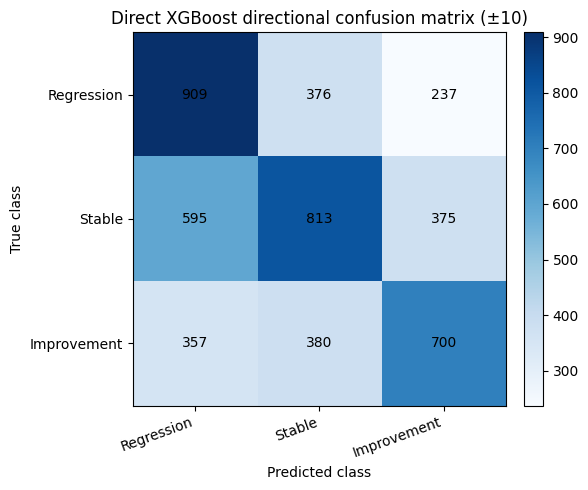

In [7]:
# Class-level metrics and confusion matrix for the direct XGBoost classifier.
pr,rc,f1,supp=precision_recall_fscore_support(direct_pred['true_class'],direct_pred['pred_direct_xgb'],labels=CLASSES,zero_division=0)
class_detail=pd.DataFrame({'class':CLASSES,'precision':pr,'recall':rc,'F1':f1,'support':supp})
cm=confusion_matrix(direct_pred['true_class'],direct_pred['pred_direct_xgb'],labels=CLASSES)
cm_df=pd.DataFrame(cm,index=CLASSES,columns=CLASSES)
display(class_detail.round(3)); display(cm_df)

derived.to_csv(P['tables']/'06_derived_directional_metrics.csv',index=False)
derived_conf.to_csv(P['tables']/'06_derived_directional_confusion_counts.csv',index=False)
direct_pred.to_csv(P['predictions']/'06_direct_classification_predictions.csv',index=False)
pd.DataFrame(direct_tuning).to_csv(P['tables']/'06_direct_classification_tuning.csv',index=False)
direct_metrics.to_csv(P['tables']/'06_direct_classification_metrics.csv',index=False)
class_detail.to_csv(P['tables']/'06_direct_xgb_class_metrics.csv',index=False)
cm_df.to_csv(P['tables']/'06_direct_xgb_confusion_matrix.csv')


# Fold-level direct-classification stability and observed class balance.
fold_direct=[]
for fold,g in direct_pred.groupby('fold'):
    for label,col in [('Direct multinomial logistic','pred_direct_logistic'),('Direct XGBoost classifier','pred_direct_xgb')]:
        fold_direct.append({'fold':fold,'approach':label,**class_metrics(g['true_class'],g[col])})
fold_direct=pd.DataFrame(fold_direct)
class_balance=(pd.Series(classify_change(oof[TARGET]-oof['perf_rank_t'],THRESH)).value_counts().reindex(CLASSES).rename_axis('class').reset_index(name='n'))
class_balance['share']=class_balance['n']/class_balance['n'].sum()
display(fold_direct.round(3))
display(class_balance)
fold_direct.to_csv(P['tables']/'06_direct_classification_by_fold.csv',index=False)
class_balance.to_csv(P['tables']/'06_direction_class_balance_threshold10.csv',index=False)

fig,ax=plt.subplots(figsize=(6,5))
im=ax.imshow(cm,cmap='Blues')
ax.set_xticks(range(len(CLASSES)),CLASSES,rotation=20,ha='right'); ax.set_yticks(range(len(CLASSES)),CLASSES)
ax.set_xlabel('Predicted class'); ax.set_ylabel('True class'); ax.set_title('Direct XGBoost directional confusion matrix (±10)')
for r in range(cm.shape[0]):
    for c in range(cm.shape[1]): ax.text(c,r,int(cm[r,c]),ha='center',va='center')
fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04); fig.tight_layout(); fig.savefig(P['figures']/'06_direct_xgb_confusion_matrix.png',dpi=160,bbox_inches='tight'); plt.show()


### Directional result interpretation

Direct three-class XGBoost improves on classes obtained by thresholding the regression forecasts, but directional performance remains moderate and the stable class is the most difficult to identify consistently. The classification extension is therefore informative for screening and monitoring, not a high-certainty label of future player direction.

## 4. Season-specific top-20 retrieval

A recruitment or monitoring workflow may care more about who reaches a shortlist than about average numerical error. For each target season separately, the predicted top 20 is compared with the realised top 20 for two tasks: future performance **level** and largest future **improvement**. Results are averaged across the four target seasons so seasons are not pooled into a single artificial shortlist.


task,largest_improvement,next_season_level
model,,
Random Forest,0.100,0.350
Mixed-effects (BLUP),0.112,0.325
Persistence,0.000,0.312
XGBoost,0.162,0.275
ElasticNet,0.075,0.262
Ridge,0.088,0.250
LightGBM,0.125,0.250
Linear regression,0.075,0.238
Role-age-league mean,0.150,0.025


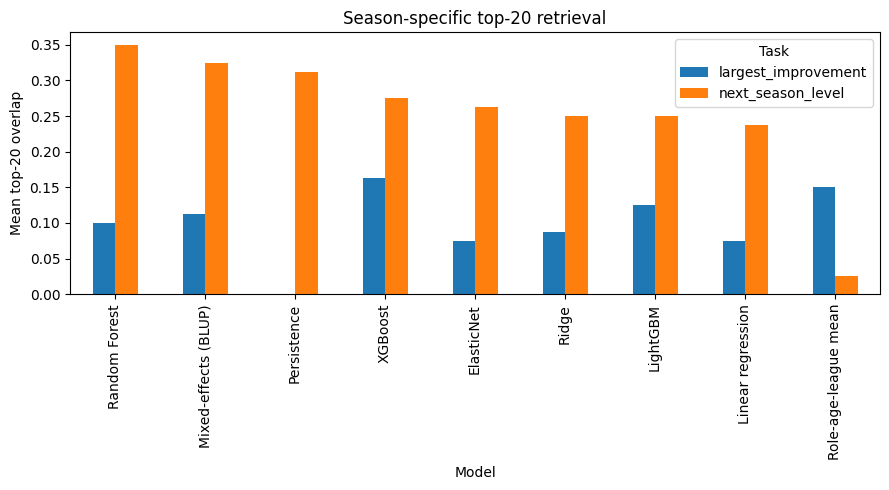

In [8]:
def topk_overlap(g,score_col,true_col,k=20):
    k=min(k,len(g))
    true=set(g.nlargest(k,true_col)['player_id'])
    pred=set(g.nlargest(k,score_col)['player_id'])
    return len(true & pred)/k

topk=[]
oof['true_change']=oof[TARGET]-oof['perf_rank_t']
for fold,g in oof.groupby('fold'):
    for name,col in model_cols.items():
        topk.append({'fold':fold,'target_season':g['target_season'].iloc[0],'model':name,'task':'next_season_level','overlap':topk_overlap(g,col,TARGET)})
        g2=g.copy(); g2['_pred_change']=g2[col]-g2['perf_rank_t']
        topk.append({'fold':fold,'target_season':g['target_season'].iloc[0],'model':name,'task':'largest_improvement','overlap':topk_overlap(g2,'_pred_change','true_change')})
topk_df=pd.DataFrame(topk)
topk_summary=topk_df.groupby(['model','task'],as_index=False)['overlap'].mean()
display(topk_summary.pivot(index='model',columns='task',values='overlap').sort_values('next_season_level',ascending=False).round(3))
topk_df.to_csv(P['tables']/'06_season_specific_top20_results.csv',index=False)
topk_summary.to_csv(P['tables']/'06_top20_mean_overlap.csv',index=False)

# Report figure: mean season-specific top-20 overlap for both practical ranking tasks.
plot_top20=topk_summary.pivot(index='model',columns='task',values='overlap').sort_values('next_season_level',ascending=False)
ax=plot_top20.plot(kind='bar',figsize=(9,5))
ax.set_ylabel('Mean top-20 overlap'); ax.set_xlabel('Model'); ax.set_title('Season-specific top-20 retrieval')
ax.legend(title='Task'); plt.tight_layout(); plt.savefig(P['figures']/'06_top20_mean_overlap.png',dpi=160,bbox_inches='tight'); plt.show()


### Shortlist interpretation

Model ranking depends on the decision task. Random Forest provides the strongest mean top-20 overlap for realised next-season performance level, whereas XGBoost performs best for the largest improvers in the current analysis. Absolute mover overlap remains low, reinforcing that identifying major future development is harder than forecasting next-season level.

## 5. Prediction intervals

Two 90% interval approaches are evaluated as separate forecasting procedures:

- **Split-conformal XGBoost:** the last season inside each outer-training window is reserved for calibration. XGBoost is fit on earlier training seasons only; the finite-sample 90th percentile of calibration absolute residuals defines a symmetric interval around test predictions. The calibration season is not used to fit that point model.
- **LightGBM quantile regression:** separate 5th- and 95th-percentile models are trained on the full outer training window.

Intervals are clipped to the target's 0–100 range. Coverage is evaluated together with width; high coverage alone is not useful if intervals are excessively broad.


In [9]:
interval_rows=[]; interval_pred=[]
# Fixed, bounded-complexity settings for the interval procedures; interval calibration is evaluated separately from point-model selection.
conf_params={'n_estimators':300,'max_depth':3,'learning_rate':0.03}
quant_params={'n_estimators':300,'max_depth':3,'learning_rate':0.03,'num_leaves':15}

for f in OUTER_FOLDS:
    train,test=split_outer(elig,f)
    proper,cal=inner_chronological_split(train,f)
    # split conformal, with preprocessing learned from proper training only
    prep=prepare_train_test(proper,cal,FEATURE_COLS,scale=False)
    m=xgb.XGBRegressor(random_state=SEED,n_jobs=-1,subsample=0.8,colsample_bytree=0.8,reg_lambda=1.0,verbosity=0,**conf_params)
    m.fit(prep.X_train,prep.train_df[TARGET].to_numpy())
    cal_pred=m.predict(prep.X_test)
    scores=np.abs(prep.test_df[TARGET].to_numpy()-cal_pred)
    n=len(scores); q_level=min(1.0,math.ceil((n+1)*0.90)/n)
    q=float(np.quantile(scores,q_level,method='higher'))
    # Transform outer test using the same proper-training preprocessing; the calibration season remains out of model fitting.
    prep_test=prepare_train_test(proper,test,FEATURE_COLS,scale=False)
    # preprocessing is deterministic from the same proper set, so feature columns must match
    assert prep.columns==prep_test.columns
    pred=m.predict(prep_test.X_test)
    lo=np.clip(pred-q,0,100); hi=np.clip(pred+q,0,100)

    # Quantile LightGBM on full outer training set, independently fitted for lower/upper bounds
    prep_q=prepare_train_test(train,test,FEATURE_COLS,scale=False)
    qmodels=[]
    for alpha in [0.05,0.95]:
        qm=lgb.LGBMRegressor(objective='quantile',alpha=alpha,random_state=SEED,n_jobs=-1,verbosity=-1,subsample=0.8,colsample_bytree=0.8,**quant_params)
        qm.fit(prep_q.X_train,prep_q.train_df[TARGET].to_numpy()); qmodels.append(qm.predict(prep_q.X_test))
    qlo=np.minimum(qmodels[0],qmodels[1]); qhi=np.maximum(qmodels[0],qmodels[1]); qlo=np.clip(qlo,0,100); qhi=np.clip(qhi,0,100)

    fr=test[['player_id','role','minutes_t','n_hist_seasons']].copy(); fr['fold']=f['fold']; fr['y_true']=test[TARGET].to_numpy()
    fr['conformal_pred']=pred; fr['conformal_lower']=lo; fr['conformal_upper']=hi; fr['conformal_q']=q
    fr['lgbq_lower']=qlo; fr['lgbq_upper']=qhi
    interval_pred.append(fr)

interval_pred=pd.concat(interval_pred,ignore_index=True)

def interval_metric(df,lo,hi):
    cover=((df['y_true']>=df[lo]) & (df['y_true']<=df[hi])).mean()
    return {'n':len(df),'coverage':float(cover),'mean_width':float((df[hi]-df[lo]).mean())}
interval_summary=pd.DataFrame([
    {'method':'Split-conformal XGBoost 90%',**interval_metric(interval_pred,'conformal_lower','conformal_upper')},
    {'method':'LightGBM quantile 90%',**interval_metric(interval_pred,'lgbq_lower','lgbq_upper')},
])
display(interval_summary.round(3))


,method,n,coverage,mean_width
0,Split-conformal XGBoost 90%,4742,0.898,64.240
1,LightGBM quantile 90%,4742,0.864,65.284


,breakdown,category,method,n,coverage,mean_width
0,role,DF,Split-conformal XGBoost 90%,2121,0.874,65.361
1,role,FW,Split-conformal XGBoost 90%,1067,0.887,63.632
2,role,MF,Split-conformal XGBoost 90%,1554,0.938,63.127
3,minutes_band,High (>=median),Split-conformal XGBoost 90%,2331,0.918,63.715
4,minutes_band,Low (<median),Split-conformal XGBoost 90%,2411,0.878,64.747
5,history_band,No history,Split-conformal XGBoost 90%,579,0.862,66.113
6,history_band,One prior season,Split-conformal XGBoost 90%,675,0.914,64.985
7,history_band,Two or more prior seasons,Split-conformal XGBoost 90%,3488,0.901,63.784


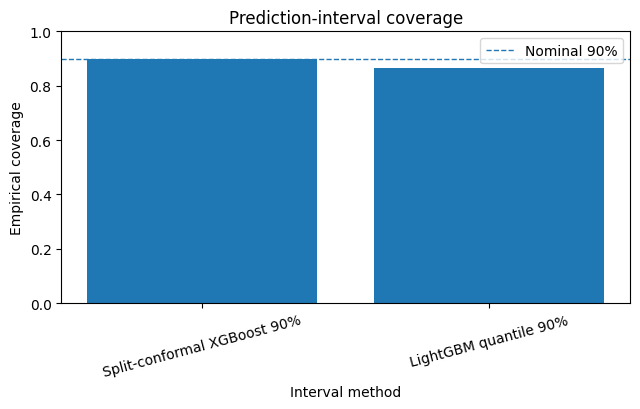

In [10]:
# Conformal subgroup coverage aligned with the point-error audit.
interval_pred['minutes_band']=np.where(interval_pred['minutes_t']>=minutes_cut,'High (>=median)','Low (<median)')
interval_pred['history_band']=np.select([interval_pred['n_hist_seasons']==0,interval_pred['n_hist_seasons']==1],['No history','One prior season'],default='Two or more prior seasons')
int_sub=[]
for breakdown in ['role','minutes_band','history_band']:
    for cat,g in interval_pred.groupby(breakdown,observed=True):
        int_sub.append({'breakdown':breakdown,'category':str(cat),'method':'Split-conformal XGBoost 90%',**interval_metric(g,'conformal_lower','conformal_upper')})
interval_subgroups=pd.DataFrame(int_sub)
display(interval_subgroups.round(3))
interval_pred.to_csv(P['predictions']/'06_prediction_interval_predictions.csv',index=False)
interval_summary.to_csv(P['tables']/'06_prediction_interval_metrics.csv',index=False)
interval_subgroups.to_csv(P['tables']/'06_prediction_interval_subgroups.csv',index=False)

# Report figure: empirical interval coverage against the nominal 90% target.
fig,ax=plt.subplots(figsize=(6.5,4.2))
ax.bar(interval_summary['method'],interval_summary['coverage'])
ax.axhline(0.90,linestyle='--',linewidth=1,label='Nominal 90%')
ax.set_ylim(0,1); ax.set_ylabel('Empirical coverage'); ax.set_xlabel('Interval method'); ax.set_title('Prediction-interval coverage')
ax.tick_params(axis='x',rotation=15); ax.legend(); fig.tight_layout(); fig.savefig(P['figures']/'06_prediction_interval_coverage.png',dpi=160,bbox_inches='tight'); plt.show()


### Interval interpretation

Split-conformal XGBoost achieves empirical coverage close to the nominal 90% level, but the resulting intervals are wide. Coverage is weaker for several of the same populations that show larger point errors, including lower-minute players and players with limited prior history. The interval results therefore support reporting uncertainty alongside any individual point forecast.

## 6. Player-cluster bootstrap model comparisons

Because some players contribute predictions in multiple test seasons, resampling individual rows would treat repeated observations as independent. The bootstrap therefore samples `player_id` clusters with replacement. The intervals quantify player-level uncertainty in paired MAE differences; they do not create additional independent seasons and should not be interpreted as proof of long-horizon temporal stability.


In [11]:
rng=np.random.default_rng(SEED)
player_groups={pid:g.index.to_numpy() for pid,g in oof.groupby('player_id')}
players=np.array(list(player_groups),dtype=object)
comparisons=[
    ('XGBoost minus Ridge','pred_xgboost','pred_ridge'),
    ('XGBoost minus Persistence','pred_xgboost','pred_persistence'),
    ('Mixed BLUP minus fixed-only','pred_mixed_blup','pred_mixed_fixed'),
]
boot_rows=[]
B=2000
for label,a,b in comparisons:
    vals=[]
    for _ in range(B):
        sampled=rng.choice(players,size=len(players),replace=True)
        idx=np.concatenate([player_groups[p] for p in sampled])
        y=oof.loc[idx,TARGET].to_numpy(); pa=oof.loc[idx,a].to_numpy(); pb=oof.loc[idx,b].to_numpy()
        vals.append(np.mean(np.abs(y-pa))-np.mean(np.abs(y-pb)))
    vals=np.asarray(vals)
    observed=np.mean(np.abs(oof[TARGET]-oof[a]))-np.mean(np.abs(oof[TARGET]-oof[b]))
    boot_rows.append({'comparison':label,'observed_MAE_difference':observed,'bootstrap_mean':vals.mean(),
                      'CI_2.5':np.quantile(vals,.025),'CI_97.5':np.quantile(vals,.975),'share_below_zero':(vals<0).mean(),'B':B})
bootstrap=pd.DataFrame(boot_rows)
display(bootstrap.round(4))
bootstrap.to_csv(P['tables']/'06_player_cluster_bootstrap_comparisons.csv',index=False)


,comparison,observed_MAE_difference,bootstrap_mean,CI_2.5,CI_97.5,share_below_zero,B
0,XGBoost minus Ridge,-0.3772,-0.3797,-0.5173,-0.2338,1.0,2000
1,XGBoost minus Persistence,-1.7189,-1.7171,-2.0567,-1.3927,1.0,2000
2,Mixed BLUP minus fixed-only,-0.4352,-0.4349,-0.5289,-0.3412,1.0,2000


## 7. Final analytical boundary

The analysis provides a complete path from raw data to decision-oriented evaluation. Average next-season rank is forecast more accurately than persistence, but model rankings are task-dependent; difficult player populations remain visible; directional prediction is materially harder than point ranking; and uncertainty intervals must be read alongside their width. These results support a decision-support interpretation rather than an autonomous recruitment or contract decision system.


In [12]:
# Save the enriched held-out master table used for report diagnostics.
oof.to_csv(P['predictions']/'06_evaluation_master_table.csv',index=False)

# Compact report-ready summary assembled from canonical files.
pooled=pd.read_csv(P['tables']/'04_regression_metrics_pooled.csv')
ablation=pd.read_csv(P['tables']/'05_feature_group_ablation_results.csv') if (P['tables']/'05_feature_group_ablation_results.csv').exists() else pd.DataFrame()
summary={
    'n_oof':len(oof),
    'best_regression_model':pooled.sort_values('MAE').iloc[0]['model'],
    'best_regression_MAE':float(pooled.sort_values('MAE').iloc[0]['MAE']),
    'direct_xgb_macro_F1':float(direct_metrics.loc[direct_metrics['approach']=='Direct XGBoost classifier','macro_F1'].iloc[0]),
    'conformal_coverage':float(interval_summary.loc[interval_summary['method'].str.startswith('Split-conformal'),'coverage'].iloc[0]),
    'conformal_mean_width':float(interval_summary.loc[interval_summary['method'].str.startswith('Split-conformal'),'mean_width'].iloc[0]),
}
with open(P['tables']/'06_final_analysis_summary.json','w',encoding='utf-8') as f: json.dump(summary,f,indent=2)
print(summary)


{'n_oof': 4742, 'best_regression_model': 'XGBoost', 'best_regression_MAE': 17.18906790480446, 'direct_xgb_macro_F1': 0.5105841597351954, 'conformal_coverage': 0.897722479966259, 'conformal_mean_width': 64.23963165283203}
